# 04 — Avaliação e Comparação de Modelos

Avalia todos os modelos no conjunto de **teste holdout** (15% dos dados, nunca visto durante o treino).

| Modelo | Tipo |
|---|---|
| DummyClassifier | Piso mínimo |
| LogisticRegression | Baseline linear |
| ChurnMLP | Rede neural PyTorch |

**Métricas**: AUC-ROC · PR-AUC · F1-Score · Accuracy  
**Extra**: análise de threshold com custo de negócio (FP vs. FN)

In [1]:
import logging
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from src.config import MODELS_DIR, RANDOM_SEED
from src.data.loader import load_raw
from src.features.pipeline import split_data
from src.models.mlp import build_model

logging.basicConfig(level=logging.INFO, format="%(name)s — %(levelname)s — %(message)s")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("ROOT:", ROOT)

ROOT: c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp


c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp\.venv\Lib\site-packages\pandera\_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


## 1. Dados e Pré-processamento

In [2]:
df = load_raw()
X_train_val, X_test, y_train_val, y_test = split_data(df)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2, stratify=y_train_val, random_state=RANDOM_SEED,
)

# Preprocessador salvo pelo 03_training.ipynb (ajustado em X_train)
preprocessor = joblib.load(MODELS_DIR / "preprocessor.joblib")

X_train_t     = preprocessor.transform(X_train)
X_train_val_t = preprocessor.transform(X_train_val)
X_test_t      = preprocessor.transform(X_test)

print(f"Teste holdout: {len(X_test_t):,} registros | churn: {y_test.mean():.1%}")
print(f"Features: {X_test_t.shape[1]}")

src.data.loader — INFO — Carregados 7043 registros × 21 colunas de telco_churn.csv
src.data.loader — WARNING — TotalCharges: 11 valores ausentes — preenchendo com mediana (1397.47)
src.data.loader — INFO — Validação de schema concluída — 7043 registros válidos
src.features.pipeline — INFO — Split — treino/val: 5986 registros | teste holdout: 1057 registros (15%)


Teste holdout: 1,057 registros | churn: 26.5%
Features: 30


## 2. Predições no Teste

In [3]:
# --- Dummy ---
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train_val_t, y_train_val)
y_prob_dummy = dummy.predict_proba(X_test_t)[:, 1]

# --- Logistic Regression ---
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_train_val_t, y_train_val)
y_prob_lr = lr.predict_proba(X_test_t)[:, 1]

# --- MLP ---
model = build_model(hidden_dims=[128, 64], dropout=0.3)
model.load_state_dict(torch.load(MODELS_DIR / "churn_mlp.pt", map_location="cpu"))
model.eval()

with torch.no_grad():
    logits = model(torch.tensor(X_test_t, dtype=torch.float32))
    y_prob_mlp = torch.sigmoid(logits).numpy()

print("Probabilidades computadas para os 3 modelos.")

Probabilidades computadas para os 3 modelos.


## 3. Tabela Comparativa (threshold = 0.5)

In [4]:
def metrics_row(name, y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "Modelo": name,
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC":  round(average_precision_score(y_true, y_prob), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
    }

comparison = pd.DataFrame([
    metrics_row("Dummy (most frequent)",  y_test, y_prob_dummy),
    metrics_row("Logistic Regression",    y_test, y_prob_lr),
    metrics_row("MLP (PyTorch)",          y_test, y_prob_mlp),
]).set_index("Modelo")

comparison.style.highlight_max(axis=0, color="#d4edda")

,AUC-ROC,PR-AUC,F1-Score,Accuracy
Modelo,,,,
Dummy (most frequent),0.500000,0.264900,0.000000,0.735100
Logistic Regression,0.849500,0.636800,0.623800,0.739800
MLP (PyTorch),0.845800,0.635000,0.617200,0.726600


## 4. Curvas ROC

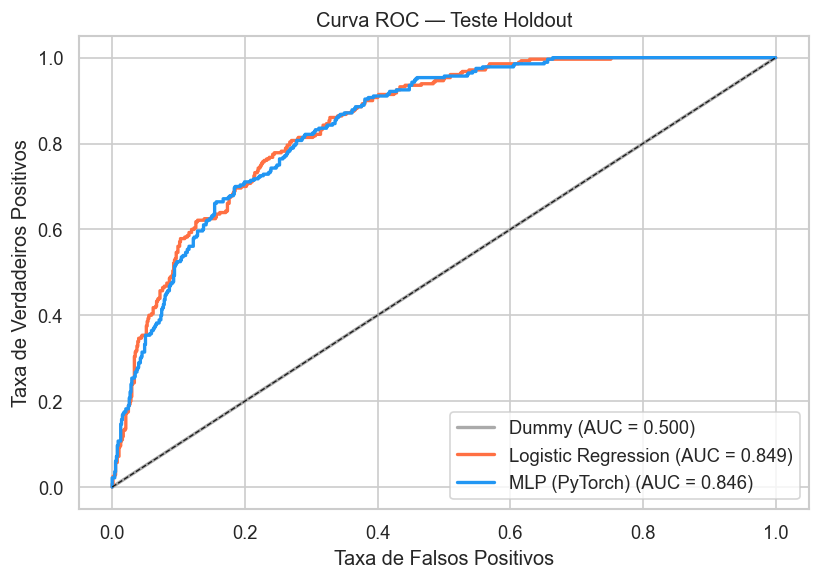

In [5]:
models_info = [
    ("Dummy",               y_prob_dummy, "#aaaaaa"),
    ("Logistic Regression", y_prob_lr,    "#FF7043"),
    ("MLP (PyTorch)",       y_prob_mlp,   "#2196F3"),
]

fig, ax = plt.subplots(figsize=(7, 5))
for name, y_prob, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC — Teste Holdout")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Curvas Precisão-Recall

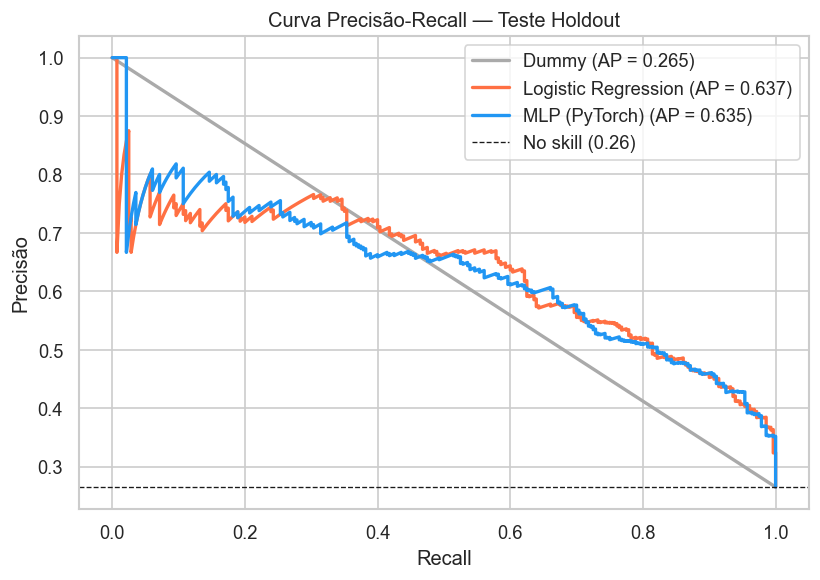

In [6]:
no_skill = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 5))
for name, y_prob, color in models_info:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f"{name} (AP = {ap:.3f})", color=color, linewidth=2)

ax.axhline(no_skill, linestyle="--", color="k", linewidth=0.8, label=f"No skill ({no_skill:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisão")
ax.set_title("Curva Precisão-Recall — Teste Holdout")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 6. Matrizes de Confusão (LR vs. MLP)

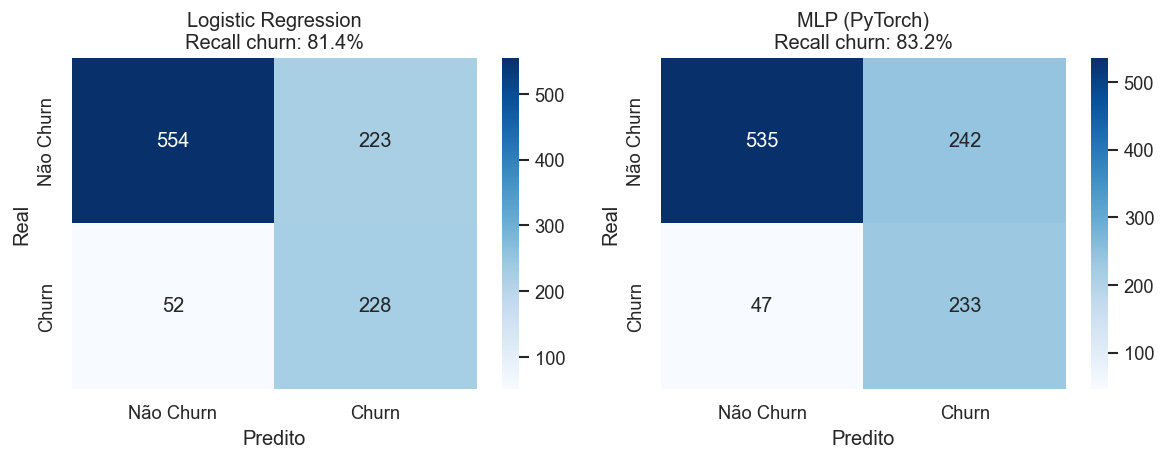

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, y_prob, _) in zip(axes, models_info[1:]):
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Não Churn", "Churn"],
        yticklabels=["Não Churn", "Churn"],
        ax=ax,
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nRecall churn: {tp/(tp+fn):.1%}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predito")

plt.tight_layout()
plt.show()

## 7. Análise de Threshold — Custo de Negócio (MLP)

Hipóteses de custo (valores ilustrativos):
- **Falso Negativo (FN)**: cliente churn não identificado → perda de receita mensal estimada em **R\$ 50**
- **Falso Positivo (FP)**: intervenção desnecessária → custo da ação de retenção estimado em **R\$ 10**

O threshold padrão de 0.5 pode não ser ótimo para esse desequilíbrio de custos.

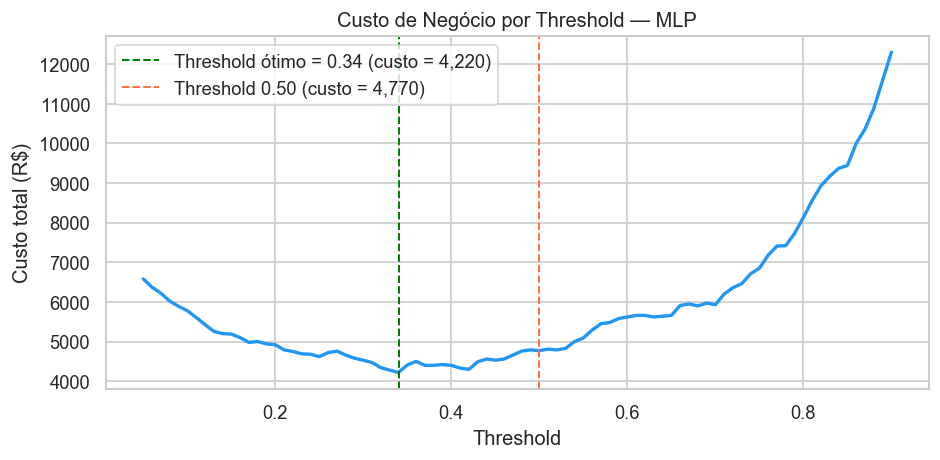

Threshold ótimo  : 0.34
Custo mínimo     : R$ 4,220
Custo threshold=0.5: R$ 4,770
Economia estimada: R$ 550 (11.5%)


In [8]:
custo_fn = 50
custo_fp = 10

thresholds = np.linspace(0.05, 0.90, 86)
custos = []

for t in thresholds:
    y_pred_t = (y_prob_mlp >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()
    custos.append(fn * custo_fn + fp * custo_fp)

idx_otimo = int(np.argmin(custos))
threshold_otimo = thresholds[idx_otimo]
custo_minimo = custos[idx_otimo]

# Custo com threshold 0.5
y_pred_05 = (y_prob_mlp >= 0.5).astype(int)
tn05, fp05, fn05, tp05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1]).ravel()
custo_05 = fn05 * custo_fn + fp05 * custo_fp

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, custos, color="#2196F3", linewidth=2)
ax.axvline(threshold_otimo, linestyle="--", color="green", linewidth=1.2,
           label=f"Threshold ótimo = {threshold_otimo:.2f} (custo = {custo_minimo:,})")
ax.axvline(0.5, linestyle="--", color="#FF7043", linewidth=1.2,
           label=f"Threshold 0.50 (custo = {custo_05:,})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Custo total (R$)")
ax.set_title("Custo de Negócio por Threshold — MLP")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Threshold ótimo  : {threshold_otimo:.2f}")
print(f"Custo mínimo     : R$ {custo_minimo:,}")
print(f"Custo threshold=0.5: R$ {custo_05:,}")
print(f"Economia estimada: R$ {custo_05 - custo_minimo:,} ({(custo_05 - custo_minimo)/custo_05:.1%})")

## 8. Métricas com Threshold Ótimo (MLP)

Threshold ótimo: 0.34
Recall churn   : 95.4%  (era 83.2% com 0.5)
Precisão churn : 42.8%  (era 49.1% com 0.5)
F1 churn       : 0.5907


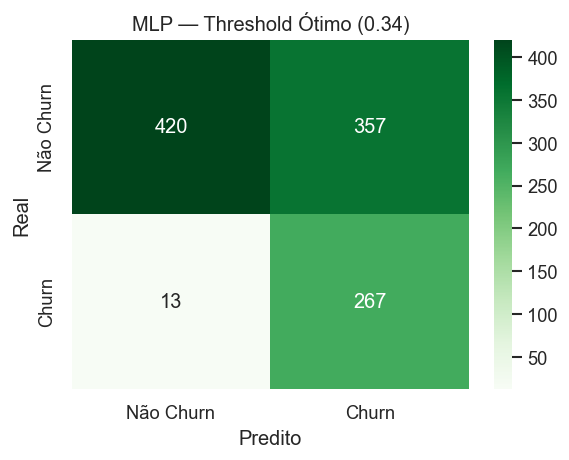

In [9]:
y_pred_otimo = (y_prob_mlp >= threshold_otimo).astype(int)
cm_otimo = confusion_matrix(y_test, y_pred_otimo)
tn_o, fp_o, fn_o, tp_o = cm_otimo.ravel()

print(f"Threshold ótimo: {threshold_otimo:.2f}")
print(f"Recall churn   : {tp_o/(tp_o+fn_o):.1%}  (era {tp05/(tp05+fn05):.1%} com 0.5)")
print(f"Precisão churn : {tp_o/(tp_o+fp_o):.1%}  (era {tp05/(tp05+fp05):.1%} com 0.5)")
print(f"F1 churn       : {f1_score(y_test, y_pred_otimo, zero_division=0):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_otimo, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Não Churn", "Churn"],
    yticklabels=["Não Churn", "Churn"],
    ax=ax,
)
ax.set_title(f"MLP — Threshold Ótimo ({threshold_otimo:.2f})")
ax.set_ylabel("Real")
ax.set_xlabel("Predito")
plt.tight_layout()
plt.show()

## 9. Conclusões

```
# Preencher com valores reais após executar o notebook
MLP AUC-ROC : [valor]
LR  AUC-ROC : [valor]
Ganho       : [delta] pontos

Threshold ótimo: [valor] (vs 0.5 padrão)
Economia de custo: [%]
```

**Decisões para o Model Card e vídeo STAR:**
- O MLP supera a Logistic Regression em AUC-ROC e PR-AUC?
- O threshold ótimo (baseado em custo) difere significativamente de 0.5?
- Qual o trade-off recall/precisão que a equipe de negócio deve aceitar?

> **Próximo passo:** `src/api/` — endpoint FastAPI de inferência (Commit 10).